# Prliminary Analysis

### dependancies and functions used in this notebook:

In [113]:
#dependancies
import os
import pandas as pd
import numpy as np
import scanpy as sc
import gseapy as gp
import matplotlib.pyplot as plt
os.makedirs("figures/step1", exist_ok=True)

def load_data(path: str, compression: str, **kwargs) -> pd.DataFrame:
    '''Loads gene expression data from a file and return as a Pandas DataFrame.'''
    df = pd.read_csv(
        path, 
        sep="\t", 
        index_col=0, 
        compression=compression, 
        **kwargs
        )
    return df

def parse_cell_name(name: str) -> dict:
    """Parse Filbin cell names into structured metadata."""
    sample = name.split("-")[0]
    
    if sample.startswith("Oligo"):
        return {"sample": sample, "patient": "Oligo", "source": "non-malignant", "model": "oligodendrocyte"}
    

    model_suffixes = ["GS", "PDX", "DGC75", "DGC100", "SF", "GF"]       #model suffixes in the filbin dataset
    parts = sample.split("_")
    patient = parts[0] 
    
    if len(parts) > 1 and parts[1] in model_suffixes:
        return {"sample": sample, "patient": patient, "source": "model", "model": parts[1]}
    else:
        return {"sample": sample, "patient": patient, "source": "patient", "model": "primary_tumor"}

data_path = "~/dmg/data/filbin/GSE102130_K27Mproject.RSEM.vh20170621.txt.gz"

### Let's import the data from the GEO dataset and inspect it

In [114]:
tpm = load_data(data_path, compression="gzip")

print(f"Shape (genes x cells): {tpm.shape}")
print(f"Value range: {tpm.values.min():.2f} to {tpm.values.max():.2f}")
print(f"Fraction of zeros: {(tpm.values == 0).mean():.2%}")
print(f"First 5 gene names: {tpm.index[:5].tolist()}")
print(f"First 5 cell names: {tpm.columns[:5].tolist()}")


Shape (genes x cells): (23686, 4058)
Value range: 0.00 to 363663.30
Fraction of zeros: 76.53%
First 5 gene names: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']
First 5 cell names: ['MUV1-P04-B12', 'MUV1-P04-C08', 'MUV1-P04-D09', 'MUV1-P04-D10', 'MUV1-P04-E03']


In [115]:
tpm.head()

,MUV1-P04-B12,MUV1-P04-C08,MUV1-P04-D09,MUV1-P04-D10,MUV1-P04-E03,MUV1-P04-E07,MUV1-P04-E08,MUV1-P04-E10,MUV1-P04-E11,MUV1-P04-F05,...,Oligo-P22-G05,Oligo-P22-G07,Oligo-P22-G11,Oligo-P22-G12,Oligo-P22-H02,Oligo-P22-H03,Oligo-P22-H05,Oligo-P22-H06,Oligo-P22-H08,Oligo-P22-H09
Gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.0,132.26,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A1CF,0.0,0.0,0.0,0.0,0.00,0.00,0.53,0.34,0.0,0.00,...,0.0,0.65,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A2M,0.0,0.0,0.0,0.0,348.48,362.08,0.00,0.00,0.0,27.17,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A2M-AS1,0.0,0.0,0.0,0.0,0.00,1.19,0.00,0.00,0.0,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1098.07,0.0


In [116]:
tumor_ids = [name.split("_")[0] for name in tpm.columns]
print(f"\nTumors found: {pd.Series(tumor_ids).value_counts().to_dict()}")


Tumors found: {'BCH869': 863, 'BCH869-P12-E03': 1, 'BCH869-P12-E05': 1, 'BCH869-P12-E06': 1, 'BCH869-P12-E07': 1, 'BCH869-P12-E08': 1, 'BCH869-P12-E09': 1, 'BCH869-P12-E10': 1, 'BCH869-P12-E12': 1, 'BCH869-P12-F03': 1, 'BCH869-P12-F04': 1, 'BCH869-P12-F05': 1, 'BCH1126-P01-E03': 1, 'BCH869-P12-F07': 1, 'BCH869-P12-F08': 1, 'BCH869-P12-F09': 1, 'BCH869-P12-F11': 1, 'BCH869-P12-G01': 1, 'BCH869-P12-G02': 1, 'BCH869-P12-G03': 1, 'BCH869-P12-G05': 1, 'BCH869-P12-G06': 1, 'BCH869-P12-G07': 1, 'BCH869-P12-G08': 1, 'BCH869-P12-F06': 1, 'BCH869-P12-B04': 1, 'BCH869-P12-B05': 1, 'BCH869-P12-B06': 1, 'BCH869-P12-B07': 1, 'BCH869-P12-B08': 1, 'BCH869-P12-B09': 1, 'BCH869-P12-B10': 1, 'BCH869-P12-B11': 1, 'BCH869-P12-C01': 1, 'BCH869-P12-C02': 1, 'BCH869-P12-C04': 1, 'BCH869-P12-E02': 1, 'BCH869-P12-C06': 1, 'BCH869-P12-C08': 1, 'BCH869-P12-C10': 1, 'BCH869-P12-C11': 1, 'BCH869-P12-C12': 1, 'BCH869-P12-D02': 1, 'BCH869-P12-D03': 1, 'BCH869-P12-D04': 1, 'BCH869-P12-D05': 1, 'BCH869-P12-D08': 1, 'B

> it seems that naming convention is PATIENT(_MODEL)-WELL POSSITION

In [117]:
meta = pd.DataFrame([parse_cell_name(n) for n in tpm.columns], index=tpm.columns)
print(meta["source"].value_counts(), "\n", "Total cell count:", meta["source"].value_counts().sum())
print("\nPatients with both primary tissue AND models:")
print(meta.groupby("patient")["model"].unique())


patient          3057
model             863
non-malignant     138
Name: source, dtype: int64 
 Total cell count: 4058

Patients with both primary tissue AND models:
patient
BCH1126                                    [primary_tumor]
BCH836                                     [primary_tumor]
BCH869     [primary_tumor, PDX, GS, DGC75, DGC100, SF, GF]
MGH101                                     [primary_tumor]
MGH104                                     [primary_tumor]
MGH66                                      [primary_tumor]
MUV1                                       [primary_tumor]
MUV10                                      [primary_tumor]
MUV5                                       [primary_tumor]
Oligo                                    [oligodendrocyte]
Name: model, dtype: object


the above numbers are higher than what was mentioned in the article. more specifically, MGH66, MGH101, MGH104 are not even mentioned in the published article. this can mean:
* the mentioned cells were added to GEO after the publication;
* or, the data is available before cell QC.

To understand which could be the case, we will run further investigations. 

## some visualization before QC

In [118]:
genes_per_cell = (tpm > 0).sum(axis=0)
total_tpm = tpm.sum(axis=0)

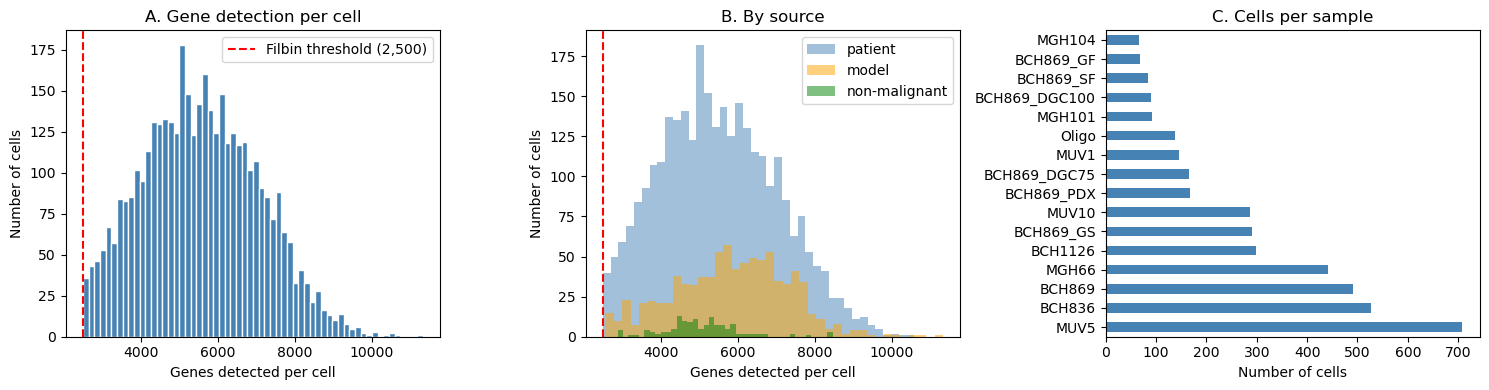

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Panel A: genes detected per cell
axes[0].hist(genes_per_cell, bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(2500, color="red", linestyle="--", label="Filbin threshold (2,500)")
axes[0].set_xlabel("Genes detected per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("A. Gene detection per cell")
axes[0].legend()

# Panel B: same, but split by sample type (patient vs model vs oligo)
for src, color in zip(["patient", "model", "non-malignant"], ["steelblue", "orange", "green"]):
    cells = meta.index[meta["source"] == src]
    axes[1].hist(genes_per_cell[cells], bins=40, alpha=0.5, label=src, color=color)
axes[1].axvline(2500, color="red", linestyle="--")
axes[1].set_xlabel("Genes detected per cell")
axes[1].set_ylabel("Number of cells")
axes[1].set_title("B. By source")
axes[1].legend()

# Panel C: cells per sample
meta["sample"].value_counts().plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_xlabel("Number of cells")
axes[2].set_title("C. Cells per sample")

plt.tight_layout()

if not os.path.exists("output/step1"):
    os.makedirs("output/step1")
    
plt.savefig("output/step1/step1_qc_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

- **Panel A**
: this shows that the distribution is unimodal, centered around 5,000–6,000 genes, and almost nothing is near the red line at 2,500; suggesting that the data in the GEO matrix is already QC-filtered.
The gap between your 4,058 and the paper's 3,321 is not mostly QC failures. Rather, it's the three extra samples (MGH66, MGH101, MGH104 — 599 cells) that aren't in the paper at all, plus the Oligo cells (138) which the paper analyzed separately, plus a smaller number of housekeeping-score or correlation-artifact removals.
- **Panel B**
: the patient/model/non-malignant split shows models (orange) skew slightly higher in gene count than patients — cleaner samples, as predicted.
- **Panel C**
: confirms the composition. MUV5 dominates, the BCH869 model is visible, three "extra" samples at the bottom.

Found: ['PDGFRA', 'MBP', 'OLIG1', 'OLIG2', 'GFAP', 'PTPRC', 'CD74']


/tmp/ipykernel_1778300/2043838441.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_src, labels=["patient", "model", "non-malignant (Oligo)"])
/tmp/ipykernel_1778300/2043838441.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_src, labels=["patient", "model", "non-malignant (Oligo)"])
/tmp/ipykernel_1778300/2043838441.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_src, labels=["patient", "model", "non-malignant (Oligo)"])
/tmp/ipykernel_1778300/2043838441.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_

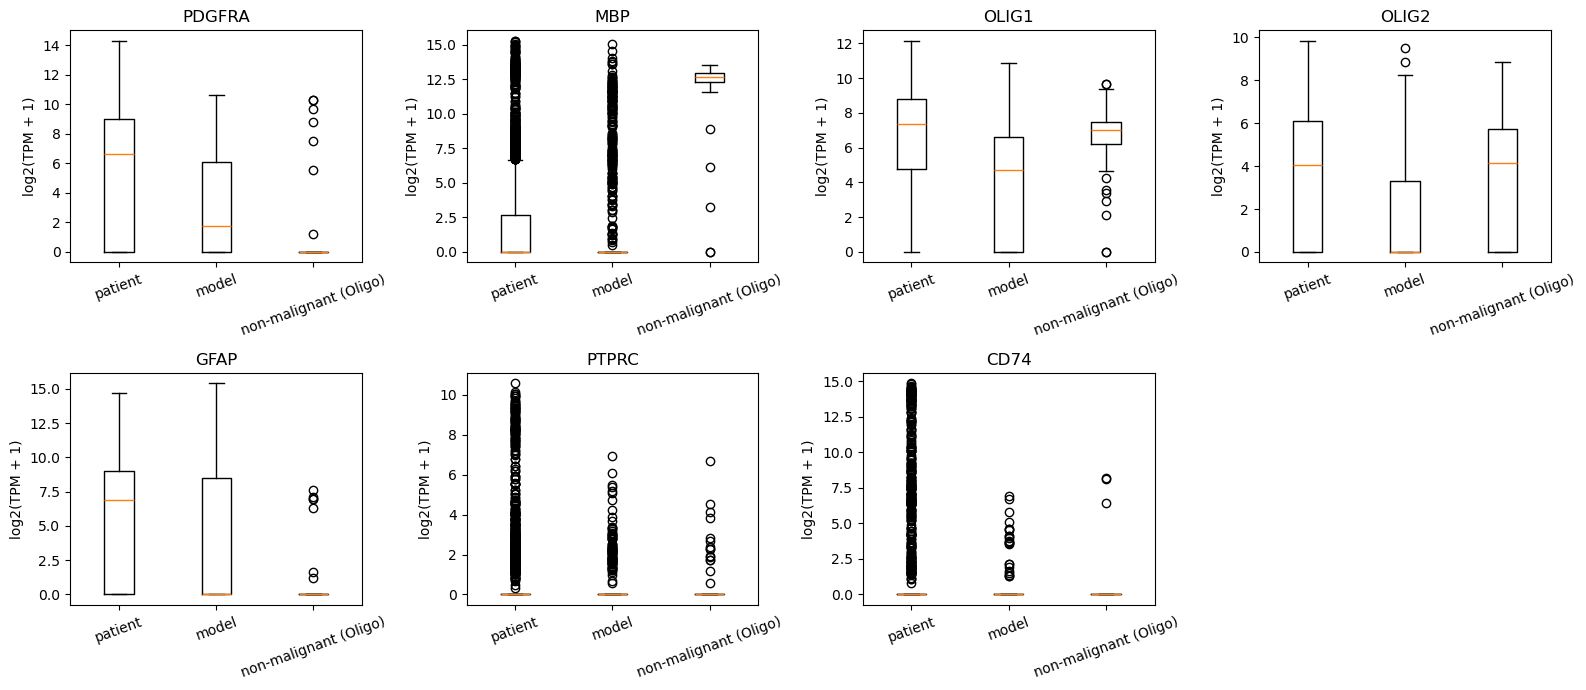

In [120]:
genes_to_check = ["PDGFRA", "MBP", "OLIG1", "OLIG2", "GFAP", "PTPRC", "CD74"]
# PDGFRA = OPC marker (should be HIGH in tumor cells)
# MBP    = mature oligodendrocyte marker (should be HIGH in 'Oligo' cells)
# OLIG1/2 = oligodendrocyte lineage TFs
# GFAP   = astrocyte marker
# PTPRC = CD45, immune cell marker (microglia/macrophages)
# CD74   = also immune

available = [g for g in genes_to_check if g in tpm.index]
print(f"Found: {available}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, gene in zip(axes.flat, available):
    expr = np.log2(tpm.loc[gene] + 1)
    # Box plot by sample type
    data_by_src = [expr[meta["source"] == s] for s in ["patient", "model", "non-malignant"]]
    ax.boxplot(data_by_src, labels=["patient", "model", "non-malignant (Oligo)"])
    ax.set_title(gene)
    ax.set_ylabel("log2(TPM + 1)")
    ax.tick_params(axis='x', rotation=20)

for ax in axes.flat[len(available):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("output/step1/step1_marker_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

### interpretation
Looking at each pane we can see some biological signals. I will briefly discuss each of the findings:
- **PDGFRA**
  : highest in patient cells, lower in models, near-zero in Oligo. This is the paper's central biology already visible in raw data — H3K27M tumors are OPC-like, and OPCs express PDGFRA. Normal mature oligodendrocytes don't.
- **MBP** 
  : The non-malignant Oligo group sits tight and high (~12.5), while patient/model cells are near zero with a long upward tail. That tail is the contains the clue — those high-MBP patient cells are either `contaminating oligodendrocytes` that weren't pre-labeled, or genuinely `OC-like malignant cells`. We will investigate and separate those in the malignant/non-malignant step later-on.
- **PTPRC (CD45) and CD74**
  : The box is flat at zero for all three groups, but patient cells have a huge cloud of high outliers (CD74 going up to 15). That's not noise. That's the immune compartment — microglia/macrophages infiltrating the patient tumors. Models have far fewer (cell culture has no immune system), Oligo almost none. This previews the second non-malignant population we'll need to remove.

>It is worth mentioning that for **PTPRC/CD74** the median is zero but the biological signal is entirely in the outliers. That being said, this shows why in single cell studies, we do NOT summarize a gene by its mean across all cells — the interesting cells are a minority and get averaged into invisibility. This is exactly why Filbin scored signatures per cell rather than comparing bulk averages, and it's the conceptual seed of the whole methods section.

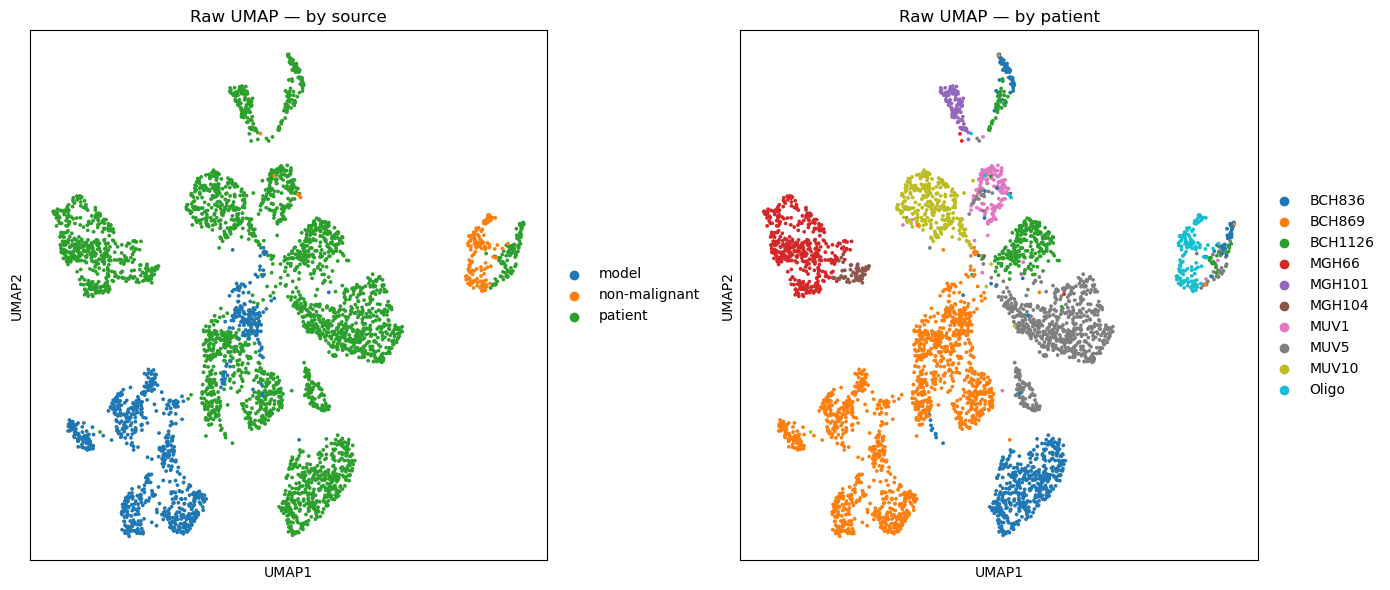

In [121]:
# Build minimal AnnData (cells x genes)
adata = sc.AnnData(X=tpm.T.values, obs=meta.copy(), var=pd.DataFrame(index=tpm.index))
adata.layers["tpm"] = adata.X.copy()

# preliminary log-transform, PCA, UMAP | no QC, no gene selection
adata.X = np.log2(adata.X + 1)
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.umap(adata, color="source", ax=axes[0], show=False, title="Raw UMAP — by source")
sc.pl.umap(adata, color="patient", ax=axes[1], show=False, title="Raw UMAP — by patient")
plt.tight_layout()
plt.savefig("output/step1/step1_raw_umap.png", dpi=150, bbox_inches="tight")
plt.show()

### interpretation
The right panel shows cells largely organized by patient. MUV5 (grey), BCH869 (orange), BCH836 (blue), MGH66 (red) each occupy their own territory. This is due to the patient effect. Because inter-patient differences (genetic background, CNVs) dominate raw structure. This is the central methodological challenge of the paper and the reason Filbin ran NMF per tumor instead of clustering everything together.
The raw data is already partially QC-filtered (unimodal gene distribution, no junk peak), so Step 2 will remove few cells. The dominant structure in the data is patient-of-origin, not cell type or biological program — this is the core problem the paper's per-tumor NMF design solves. However, biological signal is not absent: non-malignant oligodendrocytes co-cluster across patients even in a naive embedding, confirming that malignant/non-malignant separation (Steps 5–6) is feasible. Two non-malignant populations are visible in raw data: oligodendrocytes (MBP-high) and an immune compartment (PTPRC/CD74-high), both of which must be removed before studying tumor heterogeneity.

Two important observation worth talking about are:
1. left panel shows the Oligo cells (orange in left / cyan in right, far-right island) cluster together, pulled away from everything else, regardless of which patient they came from.
2. with a closer look at the right panel it is seen that the cyan island has flecks of other colors mixed in. Cells of the same cell type from different patients co-localizing despite the overwhelming patient effect.



**NOTE**

In order to form the baseline for the rest of the analysis, we will mark exclude the three extra tumors for now. The intention is not to delete them completly; rather to mark them in the metadata df and address them when the features and origins of those tumors are understood.

> the following cell deals with the labeling before furthure visualization.


In [123]:
# The paper's six H3K27M primary tumors
PAPER_TUMORS = {"MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"}


meta["in_paper_cohort"] = (
    meta["patient"].isin(PAPER_TUMORS) & (meta["source"] == "patient")
)

# Also tag the broader "verified H3K27M" set (includes models of paper tumors)
meta["is_paper_patient"] = meta["patient"].isin(PAPER_TUMORS)

print("Filbin replication cohort (primary tissue, 6 tumors):")
print(f"  {meta['in_paper_cohort'].sum()} cells")
print("\nBreakdown of what's tagged out:")
print(f"  Models of paper tumors: "
      f"{((meta['is_paper_patient']) & (meta['source']=='model')).sum()}")
print(f"  Oligo (non-malignant):  {(meta['patient']=='Oligo').sum()}")
print(f"  MGH66/101/104 (unverified): "
      f"{(~meta['is_paper_patient'] & (meta['patient']!='Oligo')).sum()}")

# Sanity: how close is the cohort to the paper's 2,458 H3K27M patient cells?
print(f"\nPaper reports 2,458 H3K27M patient cells (pre-final-QC).")
print(f"Your cohort before housekeeping filter: {meta['in_paper_cohort'].sum()}")
if meta['in_paper_cohort'].sum() == 2458:
    print("Exact match!")
else:
    print(f"Difference: {meta['in_paper_cohort'].sum() - 2458} cells")

Filbin replication cohort (primary tissue, 6 tumors):
  2458 cells

Breakdown of what's tagged out:
  Models of paper tumors: 863
  Oligo (non-malignant):  138
  MGH66/101/104 (unverified): 599

Paper reports 2,458 H3K27M patient cells (pre-final-QC).
Your cohort before housekeeping filter: 2458
Exact match!


The result printed out to the terminal(2458 cells before the filtering) shows that the reproduced workflow is consistant with the original number of cells in the filbin dataset.
That being said, the GEO matrix's 2,458 patient cells are already the post-QC set the paper used. This confirms the hypothesis from the last round: the deposited matrix is pre-filtered.

## Detailed Visualization

#### **The four questions composition plots should answer**
At the raw-data stage, we would like to know:

1. What's in the dataset? — sample composition, cell counts, source breakdown
2. What's the data quality like? — sparsity, detection rates, dynamic range
3. Are there obvious technical artifacts? — batch effects, dead cells, doublets
4. Are samples balanced enough to compare? — or will tiny samples cause noise

In [124]:
# Reusable per-cell / per-gene metrics
genes_per_cell      = (tpm > 0).sum(axis=0)
zero_frac_per_cell  = (tpm == 0).sum(axis=0) / tpm.shape[0]
detection_rate_gene = (tpm > 0).sum(axis=1) / tpm.shape[1]
total_per_cell      = tpm.sum(axis=0)

#### what is the experimental design? 

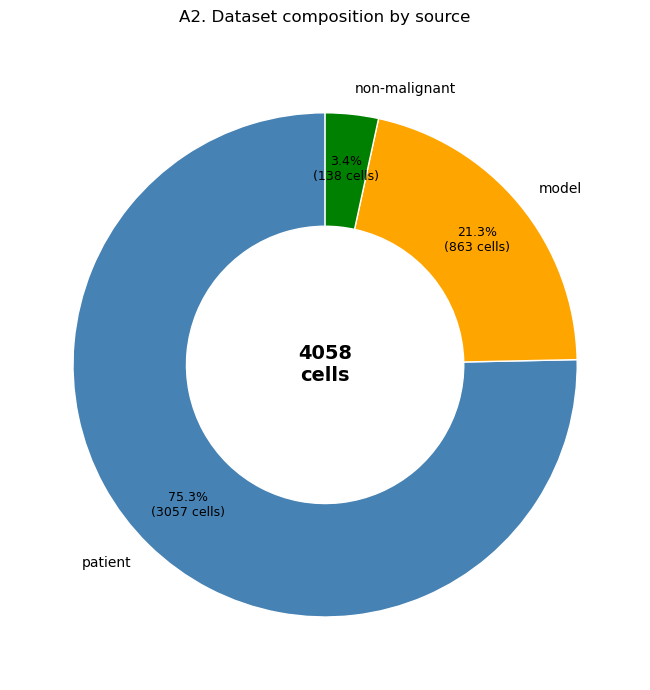

In [125]:
# A2 — Overall source split. Question: at a glance, what's the dataset made of?
counts = meta["source"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100*counts.sum()))} cells)",
    startangle=90,
    colors=["steelblue", "orange", "green"],
    wedgeprops=dict(width=0.45, edgecolor="white"),  # width<1 makes it a donut
    pctdistance=0.78,
)
plt.setp(autotexts, size=9)
ax.set_title("A2. Dataset composition by source", pad=20)

# center label = total
ax.text(0, 0, f"{counts.sum()}\ncells", ha="center", va="center",
        fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/step1/A2_source_donut.png", dpi=150, bbox_inches="tight")
plt.show()

Once again, the numbers suggst that the workflow is consistant with the numbers reported in the paper.

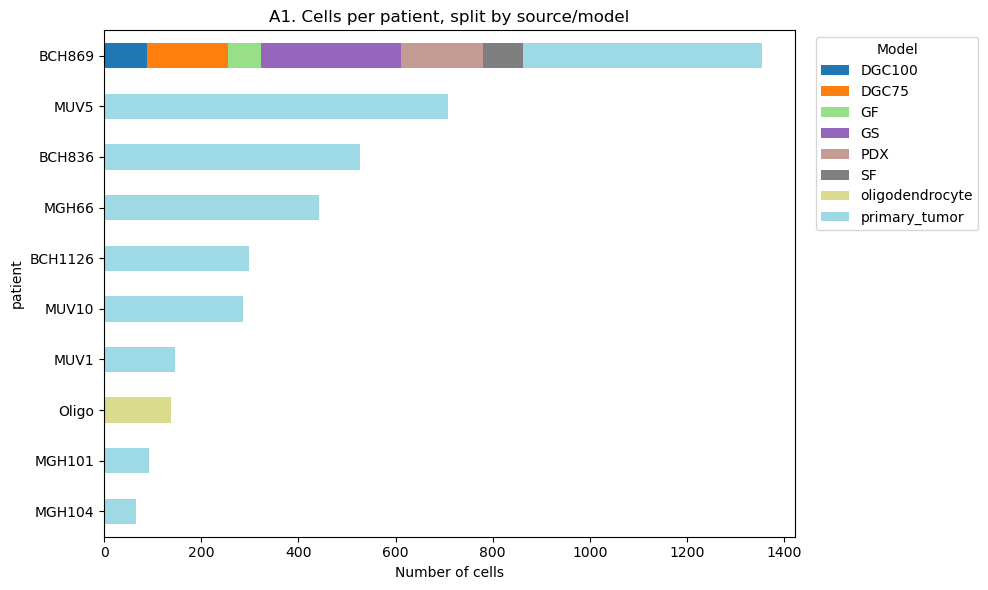

In [126]:
ct = meta.groupby(["patient", "model"]).size().unstack(fill_value=0)
# order patients by total cells
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

ax = ct.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="tab20")
ax.set_xlabel("Number of cells")
ax.set_title("A1. Cells per patient, split by source/model")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/step1/A1_composition_by_patient.png", dpi=150, bbox_inches="tight")
plt.show()

In [127]:
# Confirm: BCH869 'NA' cells are exactly the primary-tissue BCH869 cells
bch869 = meta[meta["patient"] == "BCH869"]
print(bch869.groupby(["model", "source"]).size())

model          source 
DGC100         model       89
DGC75          model      165
GF             model       68
GS             model      290
PDX            model      167
SF             model       84
primary_tumor  patient    492
dtype: int64


The cohort definition exactly reproduces the paper's counts (2,458 patient + 863 model cells), confirming both the metadata scaffold and that the GEO matrix is already post-QC. Library size is uniformly 1,000,000 → true TPM → Step 3 transform is log2(TPM/10 + 1), per Filbin. No cohort sample is low-quality (all above the 2,500 floor), but median genes/cell varies ~1.5x across cohort tumors — a technical confound that, together with the patient-dominated raw UMAP, motivates per-tumor NMF rather than global clustering. All model material derives from BCH869 alone, so any Phase 2 models-vs-primary analysis is necessarily n-of-1.

### How sparse, and is the replication cohort uniform?

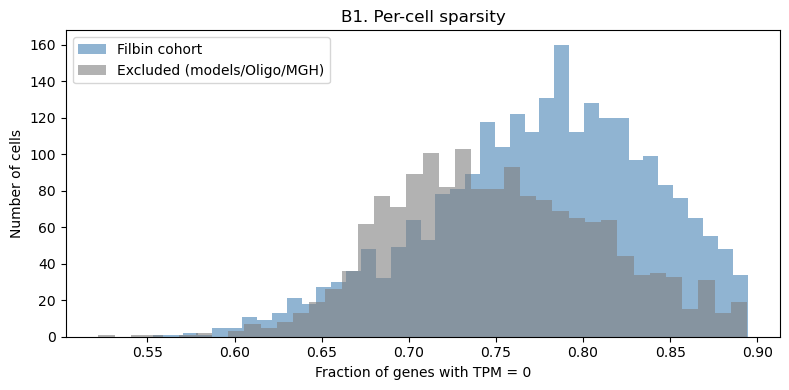

In [128]:
#B1 — Per-cell sparsity, split by cohort

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(zero_frac_per_cell[meta["in_paper_cohort"]], bins=40, alpha=0.6,
        label="Filbin cohort", color="steelblue")
ax.hist(zero_frac_per_cell[~meta["in_paper_cohort"]], bins=40, alpha=0.6,
        label="Excluded (models/Oligo/MGH)", color="grey")
ax.set_xlabel("Fraction of genes with TPM = 0")
ax.set_ylabel("Number of cells")
ax.set_title("B1. Per-cell sparsity")
ax.legend()
plt.tight_layout()
plt.savefig("figures/step1/B1_sparsity_per_cell.png", dpi=150, bbox_inches="tight")
plt.show()

Both distributions peak around 0.78–0.80 zeros which is expected results from Smart-seq2 technique.

The excluded group (grey) is shifted slightly left (less sparse, more genes detected). 
>This observation is consistant with the one seen in D1 figure which we will disscuss later; but in short, the excluded set is model/culture cells which are cleaner than primary tissue.

### How many genes are usable, what filter threshold?

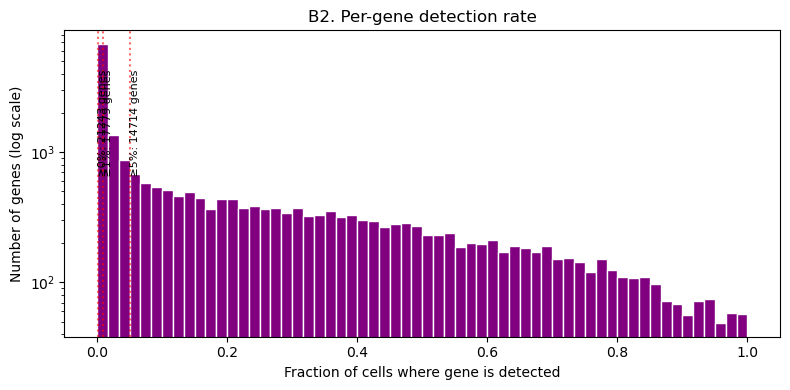

In [129]:
# B2 — Per-gene detection rate
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(detection_rate_gene, bins=60, color="purple", edgecolor="white")
ax.set_xlabel("Fraction of cells where gene is detected")
ax.set_ylabel("Number of genes (log scale)")
ax.set_title("B2. Per-gene detection rate")
ax.set_yscale("log")
# annotate how many genes survive a common filter
for thr in [0.001, 0.01, 0.05]:
    n = (detection_rate_gene >= thr).sum()
    ax.axvline(thr, color="red", linestyle=":", alpha=0.6)
    ax.text(thr, ax.get_ylim()[1]*0.5, f" ≥{thr:.0%}: {n} genes",
            rotation=90, va="top", fontsize=8)
plt.tight_layout()
plt.savefig("figures/step1/B2_detection_per_gene.png", dpi=150, bbox_inches="tight")
plt.show()

To interpret this plot we can divide it into three regions:
1. the dropout/noise zone (detection < ~1–2%)
  : there are around 25 cells (1% x 2458) in which a gene is detected. The nonzero values here are not practically informative because we can not simply decide if such values are due to biological variability or technical noise such as: ambient RNA, misalignment,and or stochastic capture.\  
  Moreover,in smart-seq2 this region is seen with high numbers because there are genes that are geniunly expressed but at levels close to the detection limit. As a result, there are flickers in the wells from cell to cell. Consequently, these reads inflate the values without providing much information. That's why in furthure steps, we will remove these reads.

2. the informative zone (detection ~5–80%)
   : These are genes detected in a meaningful but variable fraction of cells due to biological variability rather than technical noise.
3. the housekeeping zone (detection → 1.0)
   : As the detection rate suggests, these are the genes that are expressed almost in all cells suggesting that some are true housekeeping genes (ribosomal, structural, metabolic). these genes are uninformative for cell state differentiation because they are seen almost everywhere. Consequently, this area is usually excluded in variable-gene selection later-on.

### Summary
> Per-gene detection is a steep log-decay: ~1,900 genes never detected (trivially droppable), ~7,000 in a 1–5% grey zone (threshold-dependent), and a long informative tail (~5–80%) where lineage/program biology lives. Gene filtering is a noise-vs-rare-signal tradeoff. Genes at both extremes (never-detected and ubiquitous) are uninformative for clustering/NMF; the variable middle is what matters.

### TPM, TPM/10, or log? Determines normalization

Median sum per cell: 1,000,000.0
Value range overall: 0.00 to 363663.30


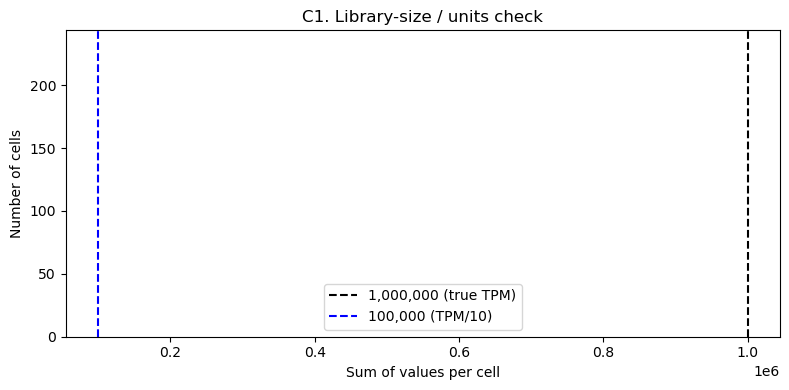

In [130]:
# C1 — Library-size check

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(total_per_cell, bins=60, color="darkred", edgecolor="white")
ax.axvline(1e6, color="black", linestyle="--", label="1,000,000 (true TPM)")
ax.axvline(1e5, color="blue",  linestyle="--", label="100,000 (TPM/10)")
ax.set_xlabel("Sum of values per cell")
ax.set_ylabel("Number of cells")
ax.set_title("C1. Library-size / units check")
ax.legend()
# print the median so you have a number, not just a picture
print(f"Median sum per cell: {np.median(total_per_cell):,.1f}")
print(f"Value range overall: {tpm.values.min():.2f} to {tpm.values.max():.2f}")
plt.tight_layout()
plt.savefig("figures/step1/C1_library_size.png", dpi=150, bbox_inches="tight")
plt.show()

A single bin sitting exactly on the 1,000,000 line, shows that every cell has essentially the same sum, so the bar is one pixel-thin spike at 1e6. This is futher confirmed by the median sum per cell printed on the terminal.

### Is any sample a batch-effect risk?

/tmp/ipykernel_1778300/2746702049.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=samples_ordered, patch_artist=True)


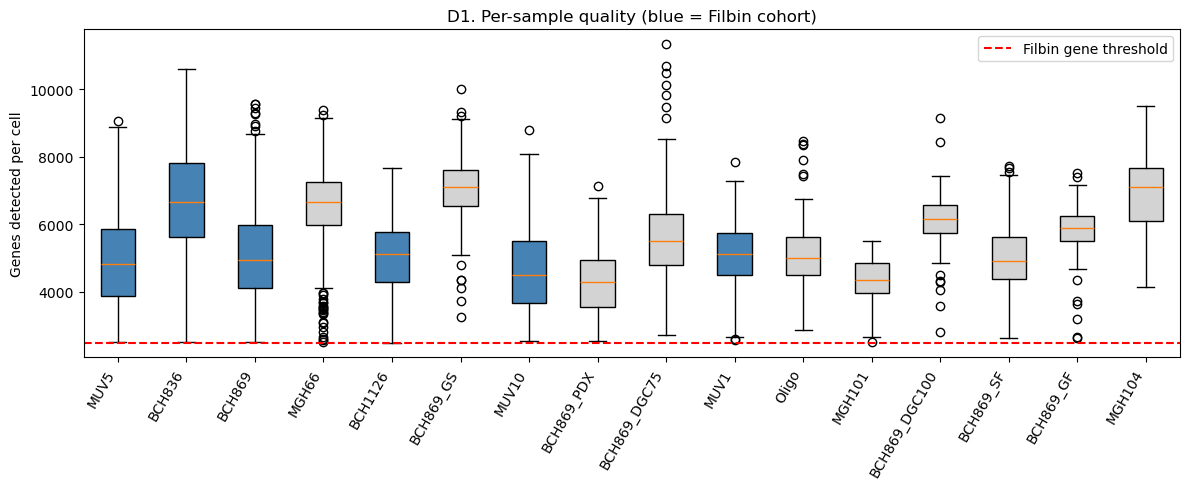

In [131]:
# D1 — Per-sample quality

fig, ax = plt.subplots(figsize=(12, 5))
samples_ordered = meta["sample"].value_counts().index
data = [genes_per_cell[meta["sample"] == s] for s in samples_ordered]
bp = ax.boxplot(data, labels=samples_ordered, patch_artist=True)
# color boxes: cohort vs excluded
for patch, s in zip(bp["boxes"], samples_ordered):
    in_cohort = meta.loc[meta["sample"] == s, "in_paper_cohort"].any()
    patch.set_facecolor("steelblue" if in_cohort else "lightgrey")
ax.axhline(2500, color="red", linestyle="--", label="Filbin gene threshold")
ax.set_xticklabels(samples_ordered, rotation=60, ha="right")
ax.set_ylabel("Genes detected per cell")
ax.set_title("D1. Per-sample quality (blue = Filbin cohort)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/step1/D1_quality_per_sample.png", dpi=150, bbox_inches="tight")
plt.show()


#### Median genes/cell varies ~1.5x across cohort tumors (BCH836 high, MUV5/BCH869 lower) — a technical confound that motivates per-tumor analysis.
This plot shows that there are no batch-effect-by-quality risk within the replication cohort. The lowest whiskers of MUV5, BCH869, MUV10, MUV1 just touch the 2,500 threshold -- a threshold that is suggested for the smart-seq2 technique and the one that was used in the filbin study.

**NOTE**
What is worth paying attention to is the fact that there's real spread in median quality across cohort tumors:
- BCH836 sits high (~6,600 median); 
- while MUV5, MUV10, BCH869 sit lower (~4,800).
That's a ~1.5–2x difference in genes detected per cell, between tumors, within the cohort. It is a variable that must be keep in mind, because technical quality differences between tumors can be interpreted as biological differences between tumors.
For the mentioned reason, Filbin ran **NMF** per tumor rather than clustering all cells together.

In [133]:
# Recompute the cohort tag directly on adata.obs
PAPER_TUMORS = {"MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"}
adata.obs["is_paper_patient"] = adata.obs["patient"].isin(PAPER_TUMORS)
adata.obs["in_paper_cohort"] = (
    adata.obs["is_paper_patient"] & (adata.obs["source"] == "patient")
)

# Verify the anchor still holds
assert adata.obs["in_paper_cohort"].sum() == 2458, \
    f"Cohort broken: got {adata.obs['in_paper_cohort'].sum()}, expected 2458"
print(f"Cohort: {adata.obs['in_paper_cohort'].sum()} cells ( matches paper)")

Cohort: 2458 cells ( matches paper)


In [134]:
sc.pp.calculate_qc_metrics(
    adata,
    layer="tpm",          # use the TPM layer, NOT adata.X (which is log)
    percent_top=None,     # skip the "top N genes %" stat (slow, not useful here)
    log1p=False,          # don't add log1p versions of metrics (TPM is already TPM)
    inplace=True,         # write into adata.obs / adata.var directly
)

In [135]:
adata.obs[["n_genes_by_counts", "total_counts"]].describe()
adata.var[["n_cells_by_counts", "mean_counts", "pct_dropout_by_counts"]].describe()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts
count,23686.000000,23686.000000,23686.000000
mean,952.494596,42.219032,76.527979
std,1046.738040,550.720751,25.794432
min,0.000000,0.000000,0.000000
25%,41.000000,0.418316,60.128142
50%,553.000000,6.014246,86.372597
75%,1618.000000,26.242308,98.989650
max,4058.000000,77048.064458,100.000000


In [136]:
# Tag gene categories in adata.var
adata.var["mt"] = adata.var_names.str.startswith("MT-")        # mitochondrial
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))  # ribosomal
adata.var["hb"] = adata.var_names.str.contains(r"^HB[^P]")     # hemoglobin (^HB but not HBP)

# Quick check that these caught something
print(f"MT genes:   {adata.var['mt'].sum()}")
print(f"Ribo genes: {adata.var['ribo'].sum()}")
print(f"Hb genes:   {adata.var['hb'].sum()}")

# Now run with categories
sc.pp.calculate_qc_metrics(
    adata,
    layer="tpm",
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

MT genes:   0
Ribo genes: 132
Hb genes:   13


In [137]:
sc.pp.calculate_qc_metrics(
    adata,
    layer="tpm",
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

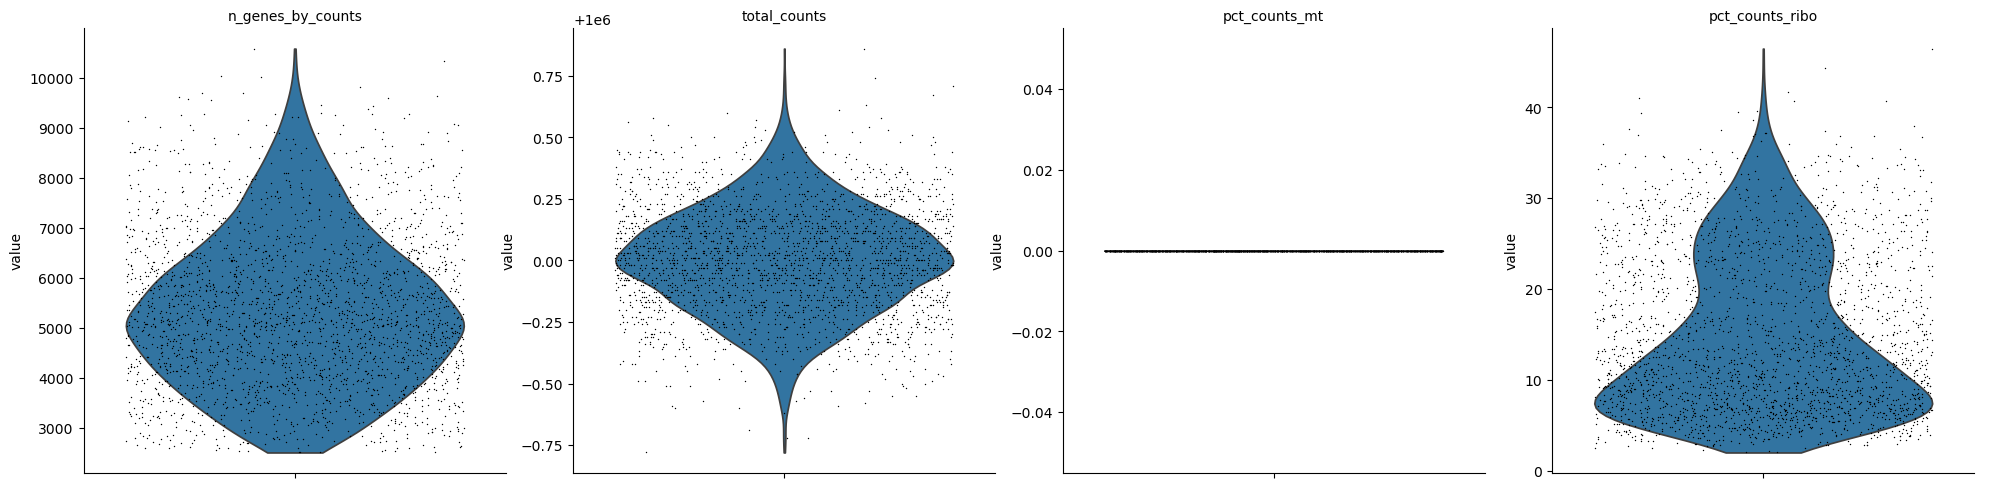

In [138]:
sc.pl.violin(
    adata[adata.obs["in_paper_cohort"]],   # plot cohort only
    keys=["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

MT genes absent from matrix (RSEM reference likely excluded chrM); MT-based QC is not applicable. FACS viability sorting before sequencing serves the same function.

QC metrics post-hoc diagnostic. n_genes_by_counts confirms all cohort cells exceed the 2,500 floor (consistent with D1). total_counts is uninformative for TPM data (library size locked to 1M by RSEM construction — the +1e6 axis annotation reflects this). pct_counts_mt is zero across all cells: MT genes are absent from the Filbin matrix (RSEM reference likely excluded chrM), and FACS viability sorting before sequencing serves the same QC role. pct_counts_ribo shows bimodal structure (~10% and ~20% modes), reflecting biological variation in translational/proliferative activity — useful as a covariate to keep in mind for Steps 7–9, where the cycling program may correlate with this signal.

## STEP 2 | HOUSEKEEPING GENE FILTERING 

In [139]:
# Eisenberg & Levanon 2013 housekeeping list (canonical source)
HK_URL = "https://www.tau.ac.il/~elieis/HKG/HK_genes.txt"
hk = pd.read_csv(HK_URL, sep=r"\s+", header=None, names=["gene", "refseq"])
hk_genes = hk["gene"].str.strip().unique().tolist()
print(f"Eisenberg list: {len(hk_genes)} genes")

Eisenberg list: 3804 genes


In [140]:
# Intersect with genes present in the Filbin matrix
hk_in_data = [gene for gene in hk_genes if gene in adata.var_names]
print(f"Eisenberg HK present in Filbin matrix: {len(hk_in_data)} / {len(hk_genes)}")

# Filbin's score: average of E = log2(TPM/10 + 1) across HK genes, per cell
tpm = adata.layers["tpm"]                              # cells x genes, raw TPM
hk_idx = [adata.var_names.get_loc(gene) for gene in hk_in_data]
hk_E = np.log2(tpm[:, hk_idx] / 10 + 1)               # log2(TPM/10 + 1)
adata.obs["hk_score"] = hk_E.mean(axis=1)

# How many cells fail the >2.5 threshold? (2.5 is the cutoff Filbin used to exclude low-quality cells)
n_fail_total = (adata.obs["hk_score"] <= 2.5).sum()
n_fail_cohort = ((adata.obs["hk_score"] <= 2.5) & adata.obs["in_paper_cohort"]).sum()
print(f"\nCells with hk_score <= 2.5 (overall):       {n_fail_total} / {adata.n_obs}")
print(f"Cells with hk_score <= 2.5 (Filbin cohort): {n_fail_cohort} / 2458")
print(f"\nCohort hk_score: mean={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score'].mean():.2f}, "
      f"min={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score'].min():.2f}")

Eisenberg HK present in Filbin matrix: 3804 / 3804

Cells with hk_score <= 2.5 (overall):       4058 / 4058
Cells with hk_score <= 2.5 (Filbin cohort): 2458 / 2458

Cohort hk_score: mean=1.48, min=0.44


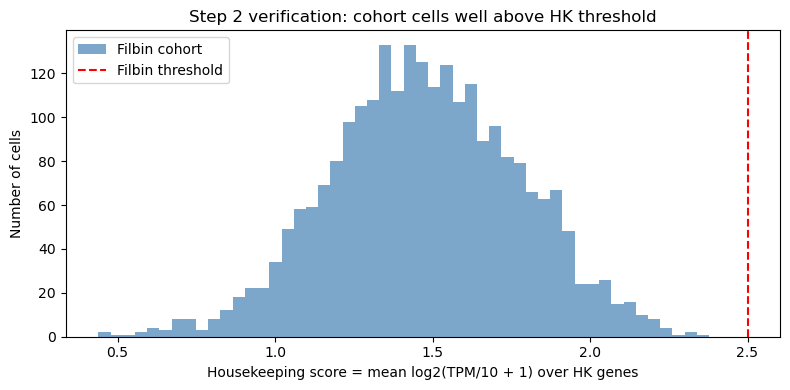

In [141]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(adata.obs.loc[adata.obs["in_paper_cohort"], "hk_score"], bins=50,
        alpha=0.7, label="Filbin cohort", color="steelblue")
ax.axvline(2.5, color="red", linestyle="--", label="Filbin threshold")
ax.set_xlabel("Housekeeping score = mean log2(TPM/10 + 1) over HK genes")
ax.set_ylabel("Number of cells")
ax.set_title("Step 2 verification: cohort cells well above HK threshold")
ax.legend()
plt.tight_layout()
plt.savefig("./figures/step2/hk_score.png", dpi=150, bbox_inches="tight")
plt.show()

In [142]:
# Read the Hounkpe list — .grp format has 2 header lines, then 1 gene per line
hounkpe = pd.read_csv(
    "~/dmg/data/references/HOUNKPE_HOUSEKEEPING_GENES.v2026.1.Hs.grp",
    skiprows=2,        # skip the two-line MSigDB header
    header=None,
    names=["gene"],
)
hk_genes_hounkpe = hounkpe["gene"].str.strip().unique().tolist()
print(f"Hounkpe list loaded: {len(hk_genes_hounkpe)} genes")
print(f"First 5: {hk_genes_hounkpe[:5]}")

Hounkpe list loaded: 1129 genes
First 5: ['AAMP', 'AAR2', 'AARS1', 'AARSD1', 'AASDHPPT']


In [143]:
hk_in_data_h = [g for g in hk_genes_hounkpe if g in adata.var_names]
print(f"Hounkpe HK present in Filbin matrix: {len(hk_in_data_h)} / {len(hk_genes_hounkpe)}")

tpm = adata.layers["tpm"]
hk_idx_h = [adata.var_names.get_loc(g) for g in hk_in_data_h]
hk_E_h = np.log2(tpm[:, hk_idx_h] / 10 + 1)
adata.obs["hk_score_hounkpe"] = hk_E_h.mean(axis=1)

cohort_mask = adata.obs["in_paper_cohort"]
print(f"\nHounkpe score on cohort: "
      f"mean={adata.obs.loc[cohort_mask, 'hk_score_hounkpe'].mean():.2f}, "
      f"min={adata.obs.loc[cohort_mask, 'hk_score_hounkpe'].min():.2f}, "
      f"max={adata.obs.loc[cohort_mask, 'hk_score_hounkpe'].max():.2f}")
print(f"Cells <= 2.5 (cohort): "
      f"{((adata.obs['hk_score_hounkpe'] <= 2.5) & cohort_mask).sum()} / 2458")

Hounkpe HK present in Filbin matrix: 1090 / 1129

Hounkpe score on cohort: mean=1.82, min=0.45, max=2.86
Cells <= 2.5 (cohort): 2412 / 2458


In [144]:
# Compare to Eisenberg
print("\nScore distributions:")
print(f"Eisenberg: mean={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score'].mean():.2f}, "
      f"min={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score'].min():.2f}, "
      f"max={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score'].max():.2f}")
print(f"Hounkpe:   mean={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score_hounkpe'].mean():.2f}, "
      f"min={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score_hounkpe'].min():.2f}, "
      f"max={adata.obs.loc[adata.obs['in_paper_cohort'], 'hk_score_hounkpe'].max():.2f}")

n_fail = ((adata.obs["hk_score_hounkpe"] <= 2.5) & adata.obs["in_paper_cohort"]).sum()
print(f"\nCohort cells with hk_score_hounkpe <= 2.5: {n_fail} / 2458")


Score distributions:
Eisenberg: mean=1.48, min=0.44, max=2.38
Hounkpe:   mean=1.82, min=0.45, max=2.86

Cohort cells with hk_score_hounkpe <= 2.5: 2412 / 2458


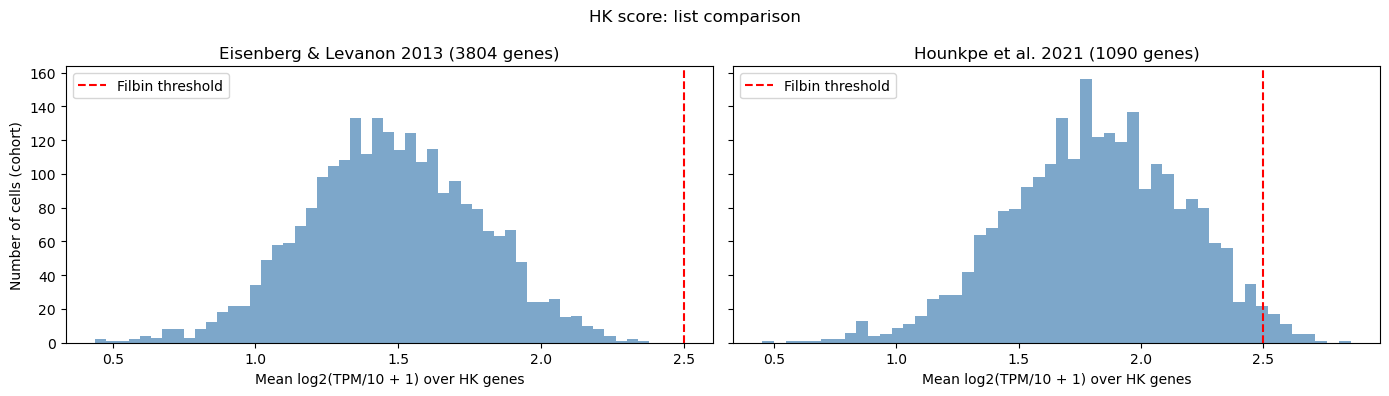

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, score_col, title in [
    (axes[0], "hk_score",         f"Eisenberg & Levanon 2013 ({len(hk_in_data)} genes)"),
    (axes[1], "hk_score_hounkpe", f"Hounkpe et al. 2021 ({len(hk_in_data_h)} genes)"),
]:
    ax.hist(adata.obs.loc[adata.obs["in_paper_cohort"], score_col], bins=50,
            color="steelblue", alpha=0.7)
    ax.axvline(2.5, color="red", linestyle="--", label="Filbin threshold")
    ax.set_xlabel(f"Mean log2(TPM/10 + 1) over HK genes")
    ax.set_title(title)
    ax.legend()
axes[0].set_ylabel("Number of cells (cohort)")
plt.suptitle("HK score: list comparison")
plt.tight_layout()
plt.savefig("figures/step2/hk_score_eisenberg_vs_hounkpe.png", dpi=150, bbox_inches="tight")
plt.show()

In [146]:
adata

AnnData object with n_obs × n_vars = 4058 × 23686
    obs: 'sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'ribo', 'hb'
    uns: 'pca', 'neighbors', 'umap', 'source_colors', 'patient_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'tpm'
    obsp: 'distances', 'connectivities'

> Before moving on, we will remove the unnecessary annotations from the `adata`. mainly because we will recompute them more correctly later.

In [147]:

'''Reset adata.X to raw TPM before freezing.
    During preliminary exploration, X was log-transformed for the raw UMAP.
    The freeze convention: layers['tpm'] = raw, X = raw at write time.
    in future we will compute log2(TPM/10 + 1) fresh from the frozen file.
'''

adata.X = adata.layers["tpm"].copy()
print(f"adata.X reset to raw TPM. Range: {adata.X.min():.2f} to {adata.X.max():.2f}")
print()

'''additionally, we will strip exploratory artifacts (UMAP, PCA, neighbor graphs) so the
    frozen file is a clean starting point.
'''

for k in list(adata.obsm.keys()):
    del adata.obsm[k]
for k in list(adata.obsp.keys()):
    del adata.obsp[k]
for k in list(adata.varm.keys()):
    del adata.varm[k]
for k in list(adata.uns.keys()):
    del adata.uns[k]
print("Stripped exploratory artifacts (obsm, obsp, varm, uns).")
print(f"adata after cleanup:\n{adata}\n")

'''                                                     #DO NOT WRITE TO THE FILE IF THESE FAIL!
Invariant checks before freezing:                       #DO NOT WRITE TO THE FILE IF THESE FAIL!
'''                                                     #DO NOT WRITE TO THE FILE IF THESE FAIL!

assert adata.n_obs == 4058,                                  f"Lost cells: n_obs={adata.n_obs}, expected 4058"
assert adata.obs["in_paper_cohort"].sum() == 2458,           f"Cohort broken: {adata.obs['in_paper_cohort'].sum()}, expected 2458"
assert (adata.obs["source"] == "model").sum() == 863,        f"Model count broken"
assert (adata.obs["patient"] == "Oligo").sum() == 138,       f"Oligo count broken"
assert "tpm" in adata.layers,                                "TPM layer missing"
assert "hk_score" in adata.obs.columns,                      "Eisenberg HK score missing"
assert "hk_score_hounkpe" in adata.obs.columns,              "Hounkpe HK score missing"
assert np.isclose(adata.X.sum(axis=1), 1e6, rtol=1e-3).all(), "X is not TPM (library sizes wrong)"
print("All invariants hold ")
print()



adata.X reset to raw TPM. Range: 0.00 to 363663.30

Stripped exploratory artifacts (obsm, obsp, varm, uns).
adata after cleanup:
AnnData object with n_obs × n_vars = 4058 × 23686
    obs: 'sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'ribo', 'hb'
    layers: 'tpm'

All invariants hold 



In [150]:
# Write the frozen file
out_path = "../data/processed/Filbin_cohort_raw.h5ad"
adata.write_h5ad(out_path)

#  Confirm the file was written and report size
size_mb = os.path.getsize(out_path) / 1024**2
print(f"  Frozen to: {out_path}")
print(f"  File size: {size_mb:.1f} MB")
print()



  Frozen to: ../data/processed/Filbin_cohort_raw.h5ad
  File size: 1468.9 MB



### check to see if the frozen file is what we expect

In [151]:

test = sc.read_h5ad(out_path)
assert test.n_obs == 4058
assert test.obs["in_paper_cohort"].sum() == 2458
assert (test.obs["source"] == "model").sum() == 863
assert (test.obs["patient"] == "Oligo").sum() == 138
assert "tpm" in test.layers
assert "hk_score" in test.obs.columns
assert "hk_score_hounkpe" in test.obs.columns
print(f"  verification passed:")
print(f"  Loaded {test.n_obs} cells, cohort = {test.obs['in_paper_cohort'].sum()}")
print(f"  Layers: {list(test.layers.keys())}")
print(f"  obs columns: {test.obs.columns.tolist()}")
del test

  verification passed:
  Loaded 4058 cells, cohort = 2458
  Layers: ['tpm']
  obs columns: ['sample', 'patient', 'source', 'model', 'is_paper_patient', 'in_paper_cohort', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'hk_score', 'hk_score_hounkpe']
